In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [ ]:
df = pd.read_csv(r"/Users/sandra/2026-orion/data/egx/ABUK.csv")

df["date"] = pd.to_datetime(df["date"]

)
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print("\nShape:", df.shape)

        date       open       high        low      close  volume
0 2015-01-04  10.666666  10.666666  10.666666  10.666666       0
1 2015-01-05  10.666666  10.800000  10.373333  10.794666  295290
2 2015-01-06  10.794666  10.800000  10.800000  10.800000  765000
3 2015-01-08  10.800000  10.400666  10.400666  10.800000     255
4 2015-01-11  10.800000  10.800000  10.800000  10.800000       0

Shape: (2857, 6)


In [3]:
df["return"] = df["close"].pct_change()

print(df[["date", "close", "return"]].head(10))

        date      close    return
0 2015-01-04  10.666666       NaN
1 2015-01-05  10.794666  0.012000
2 2015-01-06  10.800000  0.000494
3 2015-01-08  10.800000  0.000000
4 2015-01-11  10.800000  0.000000
5 2015-01-12  10.800000  0.000000
6 2015-01-13  10.800000  0.000000
7 2015-01-14  10.800000  0.000000
8 2015-01-15  10.796666 -0.000309
9 2015-01-18  10.565333 -0.021426


In [13]:
df = df.dropna(subset=["return"]).reset_index(drop=True)

print(df[["date", "return"]].head(10))

        date    return
0 2015-01-05  0.012000
1 2015-01-06  0.000494
2 2015-01-08  0.000000
3 2015-01-11  0.000000
4 2015-01-12  0.000000
5 2015-01-13  0.000000
6 2015-01-14  0.000000
7 2015-01-15 -0.000309
8 2015-01-18 -0.021426
9 2015-01-19 -0.002903


In [17]:
returns = df["return"].values.astype("float32")

In [18]:
returns = df["return"].values.astype("float32")

window = 10

In [19]:
window = 10

X = []
y = []

for i in range(window, len(returns)):
    X.append(returns[i-window:i])
    y.append(returns[i])

X = np.array(X, dtype="float32")
y = np.array(y, dtype="float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2846, 10)
y shape: (2846,)


In [22]:
class MLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = MLP(input_size=X.shape[1])

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [23]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [27]:
# Train / Test split

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([2276, 10])
X_test shape: torch.Size([570, 10])
y_train shape: torch.Size([2276])
y_test shape: torch.Size([570])


In [28]:
epochs = 300

train_losses = []
test_losses = []

for epoch in range(epochs):

    # Forward pass
    train_prediction = model(X_train)

    # Calculate training loss
    train_loss = criterion(train_prediction, y_train)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    train_loss.backward()

    # Update weights
    optimizer.step()

    # Evaluate on test data
    with torch.no_grad():
        test_prediction = model(X_test)
        test_loss = criterion(test_prediction, y_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss.item():.6f} | "
            f"Test Loss: {test_loss.item():.6f}"
        )

Epoch 50/300 | Train Loss: 0.000617 | Test Loss: 0.000629
Epoch 100/300 | Train Loss: 0.000548 | Test Loss: 0.000542
Epoch 150/300 | Train Loss: 0.000544 | Test Loss: 0.000535
Epoch 200/300 | Train Loss: 0.000543 | Test Loss: 0.000532
Epoch 250/300 | Train Loss: 0.000542 | Test Loss: 0.000530
Epoch 300/300 | Train Loss: 0.000542 | Test Loss: 0.000530


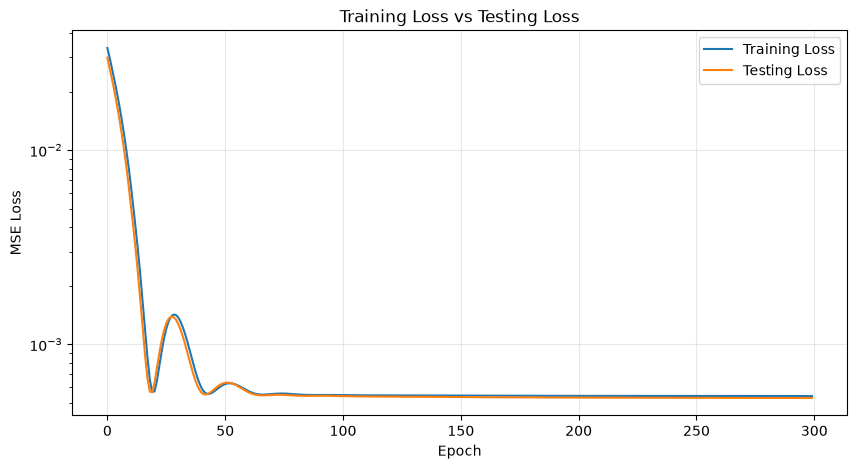

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss vs Testing Loss")

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
with torch.no_grad():
    train_predictions = model(X_train).numpy()
    test_predictions = model(X_test).numpy()

actual_train = y_train.numpy()
actual_test = y_test.numpy()

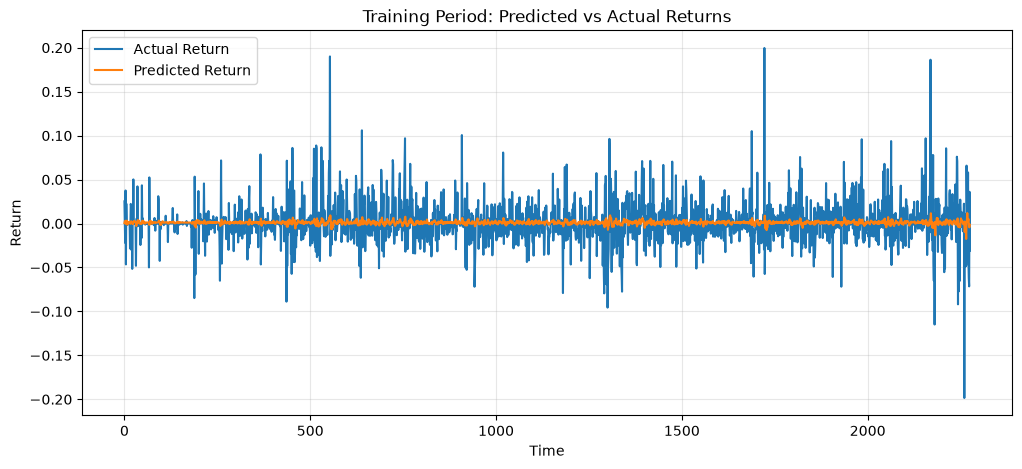

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(actual_train, label="Actual Return")
plt.plot(train_predictions, label="Predicted Return")

plt.xlabel("Time")
plt.ylabel("Return")
plt.title("Training Period: Predicted vs Actual Returns")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

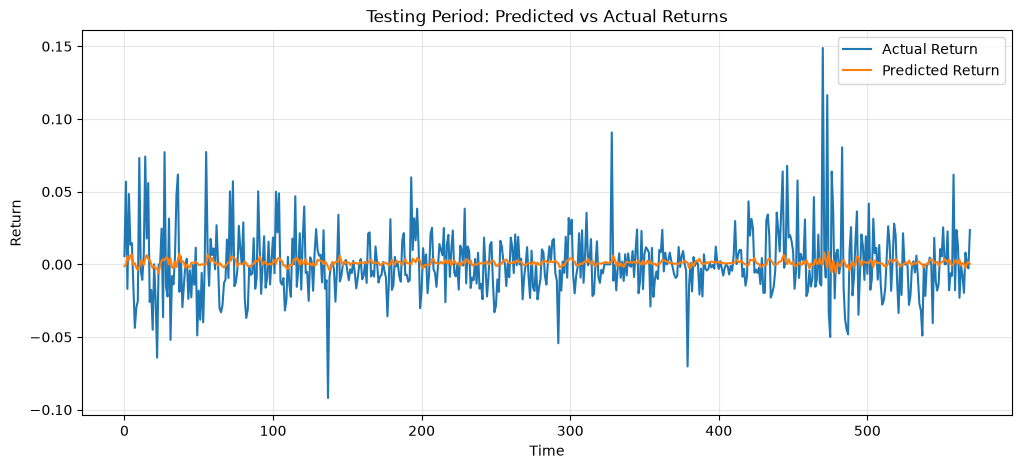

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(actual_test, label="Actual Return")
plt.plot(test_predictions, label="Predicted Return")

plt.xlabel("Time")
plt.ylabel("Return")
plt.title("Testing Period: Predicted vs Actual Returns")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
results = pd.DataFrame({
    "actual_return": actual_test,
    "predicted_return": test_predictions
})

print(results.head(15).to_string(index=False))

 actual_return  predicted_return
      0.005714         -0.001179
      0.056818         -0.000583
     -0.016897          0.005628
      0.048437          0.002931
      0.013413          0.006270
      0.014559          0.006527
     -0.014495         -0.000377
     -0.043683          0.000805
     -0.029683         -0.002412
     -0.025202         -0.003843
      0.073171         -0.001834
     -0.004546          0.002474
     -0.010654          0.002244
      0.006154         -0.000409
      0.074159          0.004169
